## Section 1: Import libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

## Section 2: Load Dataset 

In [11]:
# Define the path to the Excel file
file_path = "../data/Prediction_Data.xlsx"

# Define the sheet name to read data from
sheet_name = 'vw_ChurnData'

# Read the data from the specified sheet into a pandas DataFrame
data = pd.read_excel(file_path, sheet_name=sheet_name)

In [12]:
data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,75626-TAM,Female,32,Yes,Tamil Nadu,14,2,NaN,No,No,...,Credit Card,49.250000,255.600006,0.0,0,0.000000,255.600006,Stayed,Others,Others
1,75647-RAJ,Female,32,Yes,Rajasthan,14,20,NaN,Yes,No,...,Credit Card,53.299999,2296.250000,0.0,90,1947.150024,4333.399902,Stayed,Others,Others
2,75707-KAR,Male,28,Yes,Karnataka,2,16,Deal 4,Yes,No,...,Bank Withdrawal,20.150000,341.350006,0.0,0,616.799988,958.150024,Stayed,Others,Others
3,75712-JAM,Male,64,Yes,Jammu & Kashmir,4,32,Deal 2,Yes,No,...,Mailed Check,64.750000,3617.100098,0.0,0,1485.000000,5102.100098,Stayed,Others,Others
4,75732-HAR,Male,36,Yes,Haryana,5,35,Deal 4,Yes,No,...,Credit Card,19.950001,416.399994,0.0,0,924.210022,1340.609985,Stayed,Others,Others


## Section 3: Data Processing

In [13]:
# Drop columns that won't be used for prediction
data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)

# List of columns to be label encoded
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'
]

# Encode categorical variables except the target variable
label_encoders = {}
for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

# Manually encode the target variable 'Customer_Status'
data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# Split data into features and target
X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Section 4: Train Random Forest Model

In [14]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Section 5: Model Evaluation

In [15]:
    # Make predictions
    y_pred = rf_model.predict(X_test)

    # Evaluate the model
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Confusion Matrix:
[[774  43]
 [139 246]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.89       817
           1       0.85      0.64      0.73       385

    accuracy                           0.85      1202
   macro avg       0.85      0.79      0.81      1202
weighted avg       0.85      0.85      0.84      1202



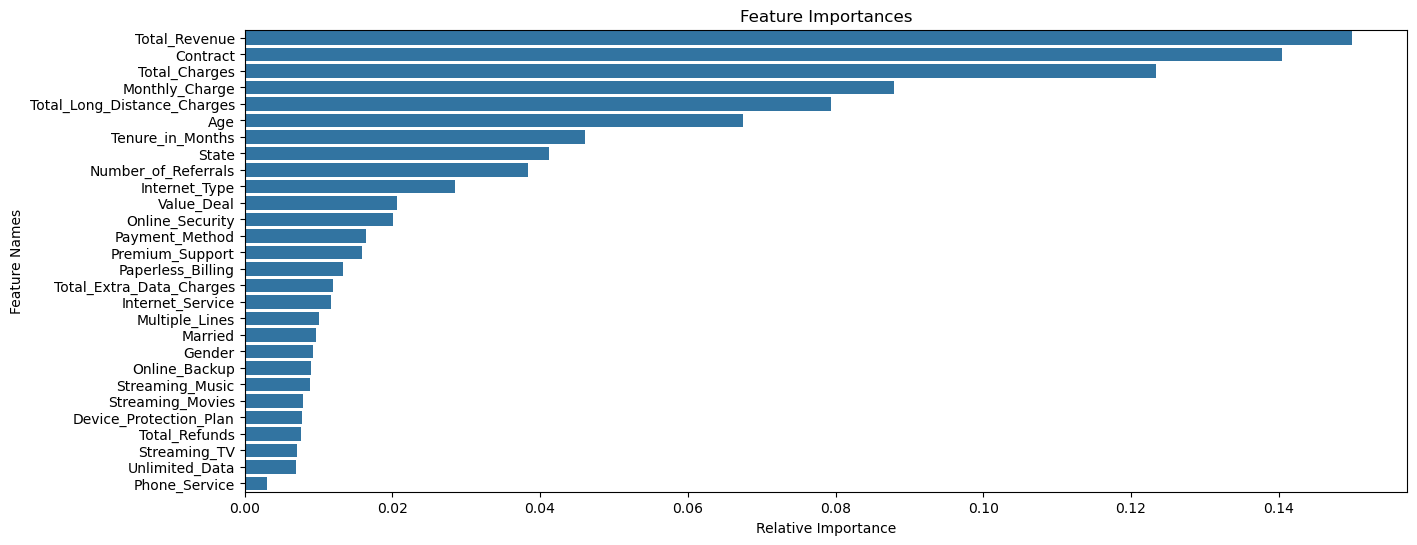

In [16]:
# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()

## Section 6: Use Prediction Model on New Data

In [19]:
# Define the path to the Joiner Data Excel file
file_path = "../data/Prediction_Data.xlsx"

# Define the sheet name to read data from
sheet_name = 'vw_JoinData'

# Read the data from the specified sheet into a pandas DataFrame
new_data = pd.read_excel(file_path, sheet_name=sheet_name)

# Display the first few rows of the fetched data
print(new_data.head())

# Retain the original DataFrame to preserve unencoded columns
original_data = new_data.copy()

# Retain the Customer_ID column
customer_ids = new_data['Customer_ID']

# Drop columns that won't be used for prediction in the encoded DataFrame
new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)

# Encode categorical variables using the saved label encoders
for column in new_data.select_dtypes(include=['object']).columns:
    new_data[column] = label_encoders[column].transform(new_data[column])

# Make predictions
new_predictions = rf_model.predict(new_data)

# Add predictions to the original DataFrame
original_data['Customer_Status_Predicted'] = new_predictions

# Filter the DataFrame to include only records predicted as "Churned"
original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

# Save the results
original_data.to_csv("../data/Predictions.csv", index=False)

  Customer_ID  Gender  Age Married           State  Number_of_Referrals  \
0   75641-PUN    Male   77      No          Punjab                    9   
1   75671-PUD  Female   34     Yes      Puducherry                    8   
2   75802-MAH  Female   61      No     Maharashtra                    4   
3   82427-MAH    Male   36      No     Maharashtra                   15   
4   82473-AND    Male   63     Yes  Andhra Pradesh                   10   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                28        NaN           Yes             No  ...   
1                13        NaN           Yes             No  ...   
2                 3        NaN           Yes             No  ...   
3                28     Deal 5           Yes             No  ...   
4                 1     Deal 5            No             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal      83.800003    163.699997           0.0   
1  Bank Wi